<i>## Comments will be provided using this format. Key takeaway: groups are encouraged to change the formatting, but not the structure. Groups are also allowed to create additional notebooks - for instance, create one notebook for data exploration, and one notebook for each preprocessing-modelling-evaluation pipeline -, but must strive to keep an unified style across notebooks.</i>

#### NOVA IMS / BSc in Data Science / Text Mining 2025/2026
### <b>Group Project: "Straining the great southern Melting Pot"</b>
#### Notebook `Notebook Title`

#### Group:
- Cyrine Moalla - 20230003
- Khadija Belhamra - 20230007
- Victoriya Mokhovikova - 20230796
- Vlad Botnev - 20230795

#### <font color='#BFD72'>Table of Contents </font> <a class="anchor" id='toc'></a> 
- [1. Data Understanding](#P1)
- [2. General Data Preparation](#P2) 
- [3. Multilabel Classification (Information Requirement 3311)](#P3)
    - [3.1 Specific Data Preparation](#P31)
    - [3.2 Model Implementation](#P32)
    - [3.3 Model Evaluation](#P3n)
- [4. Sentiment Analysis (Information Requirement 3312)](#P4)
    - [4.1 Specific Data Preparation](#P41)
    - [4.2 Model Implementation](#P42)
    - [4.3 Model Evaluation](#P43)
- [...]
- [N. Additional Tasks (Information Requirements 332n)](#Pn)
    - [N.1 Specific Data Preparation](#Pn1)
    - [N.2 Model Implementation](#Pn2)
    - [N.3 Model Evaluation](#Pn3)

<i>## Note that the notebook structure differs from the report: instead of following the CRISP-DM phases and then specifying the different problems inside the phases, the notebook is structured by problem, with the CRISP-DM phases being defined for each specific problem.

<font color='#BFD72F' size=5>1. Imports</font> <a class="anchor" id="P1"></a>

In [1]:
# General-Purpose Libraries
import os
import regex as re
import time
import unicodedata
import numpy as np
import pandas as pd

# Text Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
import html
import unicodedata

nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import networkx as nx


# Text Analysis
from collections import Counter
from nltk.util import ngrams
from textblob import TextBlob
from itertools import combinations


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/vlbotnev/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vlbotnev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vlbotnev/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


<font color='#BFD72F' size=5>1. Data Understanding</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)


In [2]:
atlanta_rest = pd.read_csv("data_atlanta/atlanta_restaurant_slice_2023.csv", header=0)
atlanta_rest

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...
...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Friday night dinner was Chicken Francaise. Jor...
53562,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Great dinner.... Yay Jordan!!!!!!
53563,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was our server and he was fantastic! Gr...
53564,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was an amazing server! Great delicious...


In [3]:
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


In [4]:
# Drop duplicates and rows without review text
atlanta_rest.drop_duplicates(subset=["text"], inplace=True)
atlanta_rest.dropna(subset=["text"], inplace=True)

In [5]:
# Drop the unneeded columns, rename the 'text' column to 'raw_text', and change its data type to 'string'.
atlanta_rest = atlanta_rest.drop(columns=["website", "url"])
atlanta_rest = atlanta_rest.rename(columns={"text": "raw_content"})
atlanta_rest["raw_content"] = atlanta_rest["raw_content"].astype(str)
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51542 entries, 0 to 53565
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         51542 non-null  object 
 1   categoryName  51542 non-null  object 
 2   reviewsCount  51542 non-null  int64  
 3   stars         51542 non-null  float64
 4   raw_content   51542 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.4+ MB


In [6]:
atlanta_rest["categoryName"].value_counts()

categoryName
Mexican restaurant          8549
Fast food restaurant        5077
Italian restaurant          4975
American restaurant         4903
Pizza restaurant            4381
Breakfast restaurant        2375
Chinese restaurant          2372
Seafood restaurant          1977
Hamburger restaurant        1924
New American restaurant     1871
Sandwich shop               1767
Steak house                 1729
Indian restaurant           1716
Chicken restaurant          1675
Japanese restaurant         1466
Mediterranean restaurant    1405
Thai restaurant             1217
Barbecue restaurant         1107
Bar & grill                 1056
Name: count, dtype: int64

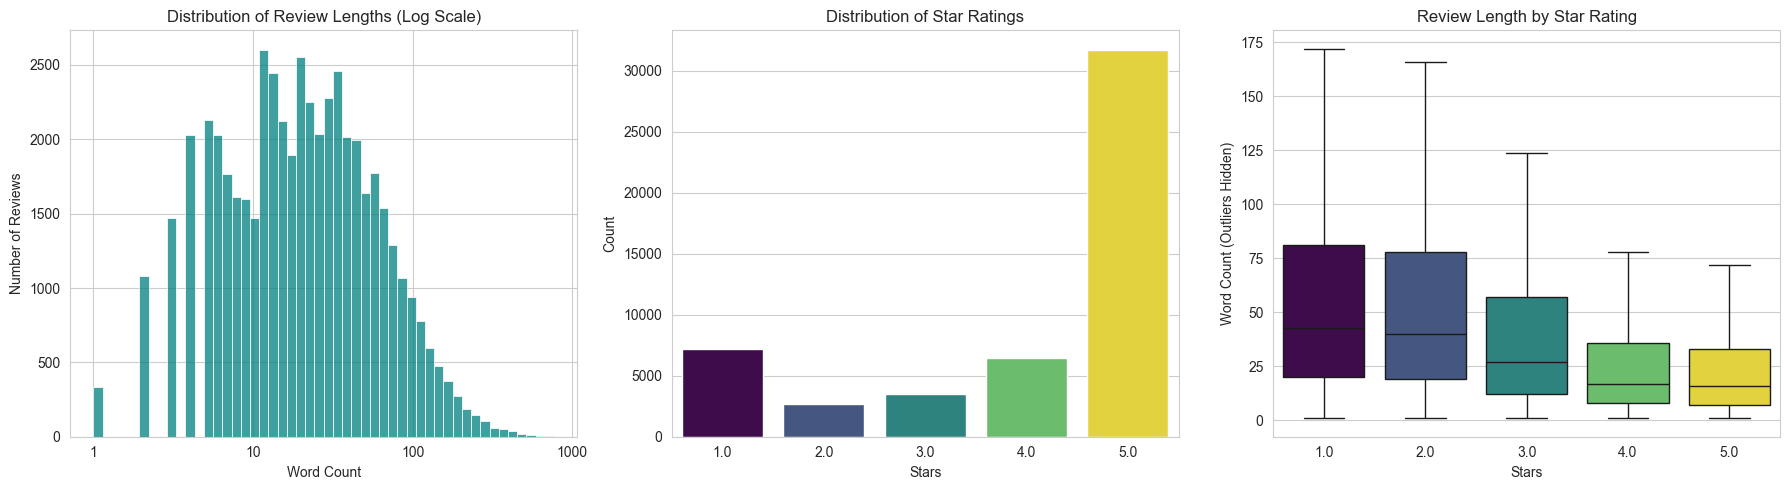

=== Descriptive Statistics: Word Counts ===


,count,mean,std,min,25%,50%,75%,max
word_count,51542.0,34.663013,45.033323,1.0,9.0,20.0,43.0,768.0



=== Class Balance: Stars ===


stars,1.0,2.0,3.0,4.0,5.0
Share of Total,0.138896,0.052695,0.067227,0.125897,0.615285


In [7]:
sns.set_style("whitegrid")

atlanta_rest["word_count"] = atlanta_rest["raw_content"].str.split().str.len()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of Review Lengths
sns.histplot(
    atlanta_rest["word_count"], bins=50, log_scale=True, ax=axes[0], color="teal"
)

axes[0].set_title("Distribution of Review Lengths (Log Scale)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Number of Reviews")

# Manually set ticks to improve readability on log scale
axes[0].set_xticks([1, 10, 100, 1000])
axes[0].get_xaxis().set_major_formatter(ticker.ScalarFormatter())
axes[0].minorticks_off()

# Star Rating Distribution
sns.countplot(
    x="stars",
    hue="stars",
    data=atlanta_rest,
    palette="viridis",
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Distribution of Star Ratings")
axes[1].set_xlabel("Stars")
axes[1].set_ylabel("Count")

# Relationship between Stars and Review Length
sns.boxplot(
    x="stars",
    y="word_count",
    hue="stars",
    data=atlanta_rest,
    showfliers=False,
    palette="viridis",
    legend=False,
    ax=axes[2],
)

axes[2].set_title("Review Length by Star Rating")
axes[2].set_xlabel("Stars")
axes[2].set_ylabel("Word Count (Outliers Hidden)")

plt.tight_layout()
plt.show()

print("=== Descriptive Statistics: Word Counts ===")
display(atlanta_rest["word_count"].describe().to_frame().T)

print("\n=== Class Balance: Stars ===")
display(
    atlanta_rest["stars"]
    .value_counts(normalize=True)
    .sort_index()
    .to_frame(name="Share of Total")
    .T
)


In [8]:
# Define thresholds for inspection
SHORT_THRESHOLD = 3
LONG_THRESHOLD = 500

short_reviews = atlanta_rest[atlanta_rest["word_count"] <= SHORT_THRESHOLD]
long_reviews = atlanta_rest[atlanta_rest["word_count"] >= LONG_THRESHOLD]

print(f"=== Extreme Value Analysis ===\n")
print(f"Extremely Short Reviews (<= {SHORT_THRESHOLD} words): {len(short_reviews)}")
print(f"Extremely Long Reviews (>= {LONG_THRESHOLD} words): {len(long_reviews)}")

print("\n--- Examples: Too Short (Potential Noise) ---")
if not short_reviews.empty:
    display(
        short_reviews[["stars", "raw_content"]].sample(
            min(5, len(short_reviews)), random_state=42
        )
    )

print("\n--- Examples: Too Long (Potential Truncation Risk) ---")
if not long_reviews.empty:
    # Show only first 200 chars to save space
    long_sample = (
        long_reviews[["stars", "raw_content"]]
        .sample(min(3, len(long_reviews)), random_state=42)
        .copy()
    )
    long_sample["raw_content"] = long_sample["raw_content"].apply(
        lambda x: x[:200] + "..."
    )
    display(long_sample)

=== Extreme Value Analysis ===

Extremely Short Reviews (<= 3 words): 2890
Extremely Long Reviews (>= 500 words): 28

--- Examples: Too Short (Potential Noise) ---


,stars,raw_content
8266,5.0,Very good food!!
21438,4.0,Damn good pizza...
42496,5.0,Lovely
50450,5.0,Best wings ever.
53366,5.0,Amazing burger



--- Examples: Too Long (Potential Truncation Risk) ---


,stars,raw_content
15101,1.0,"Every time I place an order online, I have pro..."
51288,3.0,"Aw man, I really wanted this to be 5 stars but..."
14036,1.0,HORRIBLE Experience HORRIBLE Owner\n\nI was so...


In [9]:
# Ensure word_count is calculated
if "word_count" not in atlanta_rest.columns:
    atlanta_rest["word_count"] = atlanta_rest["raw_content"].str.split().str.len()

# 1. Pearson Correlation (Linear relationship)
pearson_corr = atlanta_rest["stars"].corr(atlanta_rest["word_count"], method="pearson")

# 2. Spearman Correlation (Monotonic relationship - better for non-normal data/ranks)
spearman_corr = atlanta_rest["stars"].corr(
    atlanta_rest["word_count"], method="spearman"
)

print(f"=== Correlation Analysis: Stars vs. Review Length ===\n")
print(f"Pearson Correlation (r):   {pearson_corr:.4f}")
print(f"Spearman Correlation (ρ):  {spearman_corr:.4f}")

# Interpretation logic for the report
if spearman_corr < 0:
    print("\nInsight: Negative correlation detected.")
    print("Lower ratings tend to have longer reviews (people rant more when angry).")
elif spearman_corr > 0:
    print("\nInsight: Positive correlation detected.")
    print("Higher ratings tend to have longer reviews.")
else:
    print("\nInsight: No significant correlation found.")

=== Correlation Analysis: Stars vs. Review Length ===

Pearson Correlation (r):   -0.3025
Spearman Correlation (ρ):  -0.2828

Insight: Negative correlation detected.
Lower ratings tend to have longer reviews (people rant more when angry).


In [10]:
atlanta_rest["raw_content"].sample(5)

46884    The food here was great, I got the quesabirria...
362      Our waitress was trash, I wish I caught her na...
30691    If you're looking for good food...check - you'...
10532    I’ve been to this location more times than a f...
43260    Checkers was not a great place to eat they ran...
Name: raw_content, dtype: object

In [11]:
(atlanta_rest.groupby("title")["categoryName"].nunique().loc[lambda x: x > 1])


title
J. Christopher's    2
Name: categoryName, dtype: int64

In [12]:
jc = atlanta_rest[atlanta_rest["title"] == "J. Christopher's"]

print("Rows:", len(jc))
print("Unique reviews:", jc["raw_content"].nunique())
print("Categories:", jc["categoryName"].unique())


Rows: 372
Unique reviews: 372
Categories: ['Breakfast restaurant' 'American restaurant']


In [13]:
s = atlanta_rest["raw_content"].astype(str)

# Define regex patterns for Data Understanding
PATTERNS = {
    # 1. Rare Typography: Detects em-dashes, en-dashes, ellipses, and bullets.
    # These often require normalization (e.g., replacing '…' with '...') for standard tokenizers.
    "typography_special": re.compile(r"[\u2012-\u2015\u2026\u2022]"),
    # 2. Non-Latin Scripts: Detects any letter character that is NOT from the Latin script.
    # This effectively captures Cyrillic, Hebrew, Han (Chinese/Japanese), Arabic, etc.
    "non_latin_scripts": re.compile(r"(?!\p{Latin})\p{L}"),
    # 3. Latin Diacritics: Detects Latin characters outside the ASCII range (e.g., é, ñ, ü).
    # Useful for distinguishing between foreign languages (Spanish) and loanwords in English (café).
    "latin_diacritics": re.compile(r"(?=\p{Latin})[^\x00-\x7F]"),
    # 4. Visual Emojis: Detects standard pictographic emojis.
    "emojis_visual": re.compile(r"\p{Extended_Pictographic}"),
    # 5. Technical/Invisible Characters: Detects non-printable or control characters.
    # Includes Non-breaking space (\u00A0), Zero-width chars (\u200B-\u200F),
    # Variation Selectors (\uFE0F), and Byte Order Marks (\uFEFF).
    "technical_invisible": re.compile(r"[\u00A0\u200B-\u200F\uFE0F\uFEFF]"),
}

print("Regex patterns compiled successfully.")

Regex patterns compiled successfully.


In [14]:
# Apply patterns to the dataset to create boolean masks
results = {}
for name, pat in PATTERNS.items():
    mask = s.apply(lambda x: bool(pat.search(x)))
    results[name] = {
        "affected_reviews": mask.sum(),
        "percentage": f"{(mask.mean() * 100):.2f}%",
    }

# Create a summary DataFrame
stats_df = pd.DataFrame(results).T.sort_values("affected_reviews", ascending=False)

print("=== Corpus Auditing: Review-Level Statistics ===")
display(stats_df)

=== Corpus Auditing: Review-Level Statistics ===


,affected_reviews,percentage
typography_special,801,1.55%
latin_diacritics,687,1.33%
emojis_visual,396,0.77%
technical_invisible,331,0.64%
non_latin_scripts,48,0.09%


In [15]:
# specific code points to audit
INVISIBLE_CHARS = {
    "\u00a0": "NBSP (Non-breaking space)",
    "\u200d": "ZWJ (Zero Width Joiner)",
    "\ufe0f": "VS16 (Variation Selector-16)",
    "\u200b": "ZWSP (Zero Width Space)",
    "\ufeff": "BOM (Byte Order Mark)",
}

audit_data = []

for char_code, desc in INVISIBLE_CHARS.items():
    # Count total occurrences across the entire corpus
    total_count = s.str.count(char_code).sum()

    # Count how many documents contain at least one instance
    docs_affected = s.str.contains(char_code, regex=False).sum()

    if total_count > 0:
        audit_data.append(
            {
                "code_point": f"U+{ord(char_code):04X}",
                "description": desc,
                "total_occurrences": total_count,
                "documents_affected": docs_affected,
            }
        )

audit_df = pd.DataFrame(audit_data).sort_values("total_occurrences", ascending=False)

print("=== Technical Character Audit (Granular) ===")
display(audit_df)

=== Technical Character Audit (Granular) ===


,code_point,description,total_occurrences,documents_affected
2,U+FE0F,VS16 (Variation Selector-16),491,314
1,U+200D,ZWJ (Zero Width Joiner),81,70
0,U+00A0,NBSP (Non-breaking space),45,10
3,U+200B,ZWSP (Zero Width Space),2,2


In [16]:
def inspect_pattern_matches(mask_name, title, n=5):
    """
    Filters the dataset using the defined regex pattern and prints full examples
    for qualitative analysis.
    """
    pat = PATTERNS[mask_name]
    # Filter dataset
    mask = s.apply(lambda x: bool(pat.search(x)))
    subset = atlanta_rest[mask]

    print(f"\n{'=' * 80}")
    print(f"CATEGORY: {title}")
    print(f"Total Matches: {len(subset)}")
    print(f"{'=' * 80}\n")

    if len(subset) > 0:
        # Sample n reviews (random_state fixed for reproducibility in report)
        sample_size = min(n, len(subset))
        examples = subset.sample(sample_size, random_state=42)

        for idx, row in examples.iterrows():
            text = row["raw_content"]
            # Extract distinct matches found in this specific review
            matches = set(pat.findall(text))

            print(f"Row Index: {idx}")
            print(f"Detected Tokens: {matches}")
            print(f"Full Text:\n{text}")
            print("-" * 80)


# 1. Inspect Non-Latin Scripts (to decide on language filtering)
inspect_pattern_matches(
    "non_latin_scripts", "Non-Latin Scripts (Potential Language Outliers)", n=5
)

# 2. Inspect Latin Diacritics (to differentiate Spanish vs. Loanwords)
inspect_pattern_matches("latin_diacritics", "Latin Diacritics", n=5)

# 3. Inspect Typography (to assess tokenization risks)
inspect_pattern_matches(
    "typography_special", "Rare Typography (Dashes, Bullets, Ellipses)", n=5
)

# 4. Inspect Technical Characters (to justify cleaning)
inspect_pattern_matches("technical_invisible", "Invisible & Technical Characters", n=5)


CATEGORY: Non-Latin Scripts (Potential Language Outliers)
Total Matches: 48

Row Index: 26911
Detected Tokens: {'צ', 'ל', 'א', 'ע', 'כ', 'ת', 'מ', 'ה', 'ו'}
Full Text:
אוכל מעולה צוות מעולה
--------------------------------------------------------------------------------
Row Index: 41202
Detected Tokens: {'ω'}
Full Text:
I have been eating at Mr. Fuji for around 5 years now and I have to say. Every single time I have been here it has been such a nice experience.

Mr. Fuji has such a wonderful atmosphere. There is Japanese  art on the walls and the employees are so kind. The owner is very nice and sweet. ♡(.◜ω◝.)♡

The food is amazing. Everything is so authentic, especially the sushi. My favorite is the Volcano roll, I recommend it to anyone who is new to sushi. The food always comes out hot, fresh and delicious!

Overall 5/5 stars
--------------------------------------------------------------------------------
Row Index: 22405
Detected Tokens: {'텝', '수', '식', '음', '맛', '고', '인', '정', '

We have 19 different types of cuisine

<font color='#BFD72F' size=5>2. Data Preprocessing</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)

<i>## Use markdown cells to describe the purpose of the code cells that follow them.</i>

## 2.1 General Data Cleaning

In [17]:
pat_non_latin = PATTERNS["non_latin_scripts"]

spanish_stopwords = [
    "muy",
    "gracias",
    "pero",
    "bueno",
    "buena",
    "comida",
    "excelente",
    "servicio",
    "lugar",
    "para",
    "estoy",
    "todo",
    "bien",
    "mal",
    "nunca",
    "siempre",
    "delicioso",
    "amigos",
    "familia",
]
pat_spanish_vocab = re.compile(
    r"\b(" + "|".join(spanish_stopwords) + r")\b", re.IGNORECASE
)
pat_spanish_punct = re.compile(r"[¿¡]")

pat_german_chars = re.compile(r"[ßäöüÄÖÜ]")

raw_s = atlanta_rest["raw_content"].astype(str)

mask_non_latin = raw_s.apply(lambda x: bool(pat_non_latin.search(x)))
mask_spanish_vocab = raw_s.apply(lambda x: bool(pat_spanish_vocab.search(x)))
mask_spanish_punct = raw_s.apply(lambda x: bool(pat_spanish_punct.search(x)))
mask_german = raw_s.apply(lambda x: bool(pat_german_chars.search(x)))

mask_to_drop = mask_non_latin | mask_spanish_vocab | mask_spanish_punct | mask_german

print(f"=== Filtering Report ===")
print(f"Non-Latin Scripts detected: {mask_non_latin.sum()}")
print(f"Spanish Vocabulary detected: {mask_spanish_vocab.sum()}")
print(f"Spanish Punctuation detected: {mask_spanish_punct.sum()}")
print(f"German Characters detected: {mask_german.sum()}")
print(f"{'-' * 30}")
print(
    f"TOTAL Reviews to Drop: {mask_to_drop.sum()} ({(mask_to_drop.mean() * 100):.2f}%)"
)

print("\n--- Examples of Dropped Reviews ---")
dropped_df = atlanta_rest[mask_to_drop]
if not dropped_df.empty:
    for i, row in dropped_df.sample(
        min(5, len(dropped_df)), random_state=42
    ).iterrows():
        print(f"[{i}] {row['raw_content'][:150]}...")

initial_len = len(atlanta_rest)
atlanta_rest.drop(atlanta_rest[mask_to_drop].index, inplace=True)
print(
    f"\nDropped {initial_len - len(atlanta_rest)} rows. Final Dataset Size: {len(atlanta_rest)}"
)


def clean_text_pipeline(text):
    if not isinstance(text, str):
        return str(text)

    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"[\u2018\u2019\u0060\u00B4]", "'", text)
    text = re.sub(r"[\u2012-\u2015]", " - ", text)
    text = text.replace("\u2026", "...")
    text = text.replace("\u2022", " ")
    text = re.sub(r"[\u00A0\u200B-\u200F\uFE0F\uFEFF]", " ", text)

    text = "".join(
        c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn"
    )

    return re.sub(r"\s+", " ", text).strip().lower()


atlanta_rest["clean_text"] = atlanta_rest["raw_content"].apply(clean_text_pipeline)

=== Filtering Report ===
Non-Latin Scripts detected: 48
Spanish Vocabulary detected: 828
Spanish Punctuation detected: 11
German Characters detected: 11
------------------------------
TOTAL Reviews to Drop: 895 (1.74%)

--- Examples of Dropped Reviews ---
[46392] muy buena atención Todo está muy correcto muy limpio muy bien en un lugar bueno para ir a desayunar a comer y a cenar es excelente este lugar...
[26204] El mejor restaurant por mucho, deliciosa comida, postres, tacos deliciosos, las enchiladas, tortas, etc, etc, por mucho mi favorito, lo recomiendo amp...
[32019] Bueno.....
[46416] Excelente los tacos ...
[2934] Español - English
Tuve la oportunidad de probar este sitio hace 4 años y fue increíble, desafortunadamente esta segunda visita no fue lo mismo. Vi una...

Dropped 895 rows. Final Dataset Size: 50647


In [19]:
CONTRACTION_MAP = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so is",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have",
}


pat_contractions = re.compile(r"\b(" + "|".join(CONTRACTION_MAP.keys()) + r")\b")


def expand_contractions(text):
    def replace(match):
        return CONTRACTION_MAP[match.group(0)]

    return pat_contractions.sub(replace, text)


# Apply expansion
atlanta_rest["clean_text"] = atlanta_rest["clean_text"].apply(expand_contractions)

print("Contractions expanded (e.g., 'didn't' -> 'did not').")
print(
    "Sample check:",
    atlanta_rest.loc[
        atlanta_rest["raw_content"].str.contains("didn't", na=False), "clean_text"
    ]
    .head(1)
    .values,
)

Contractions expanded (e.g., 'didn't' -> 'did not').
Sample check: ["we had a great experience it was my hubby's birthday!! simple things make an experience amazing! we entered seated within 1 minute upon entry the vibe is very cool casual! seated and we notice in our menu it said happy birthday which was super sweet! also the hostesses were very kind and acknowledged that note on the reservation. our server kazhan b was nothing short of amazing! from our menu selections he gave us a dinning experience! we trusted his word with our selections and he did not fail at all. we had oysters to start, octopus, the ga peach salad, entrees , tuna and swordfish and the potatoes, yummy! kazhan adviced me to get the reddish, but i went with swordfish( it was a but dry, im guessing from the confit). dessert was delicious and they were kind enought to make my hubby birthday cocktails. the coconut pie was nice finish to our night and kazhan personality was on point, knowledgeable of the menu and cour

# 2.2 Preprocessing for classification

In [30]:
atlanta_rest["text_for_clf"] = atlanta_rest["clean_text"].copy()

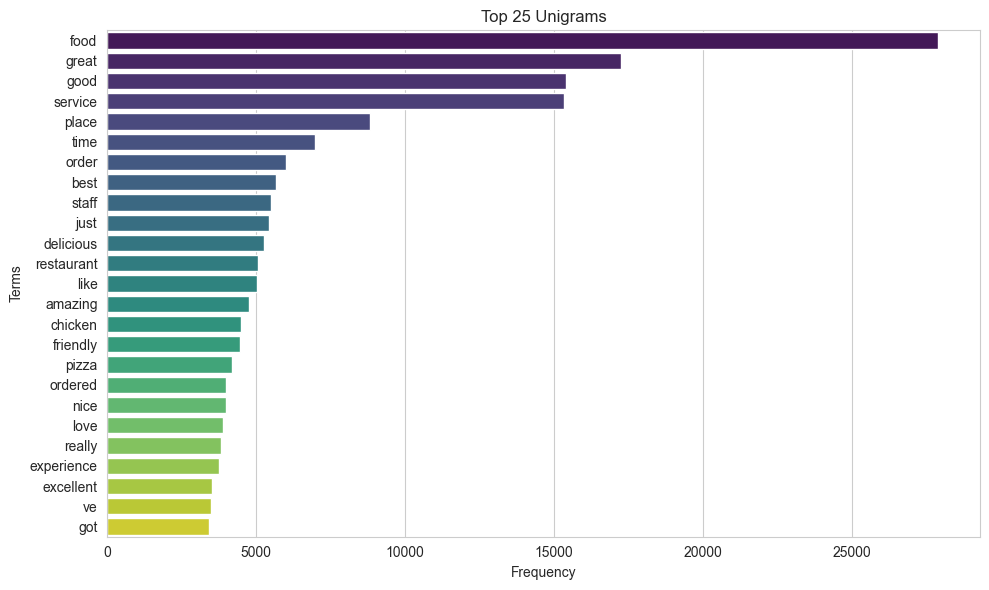

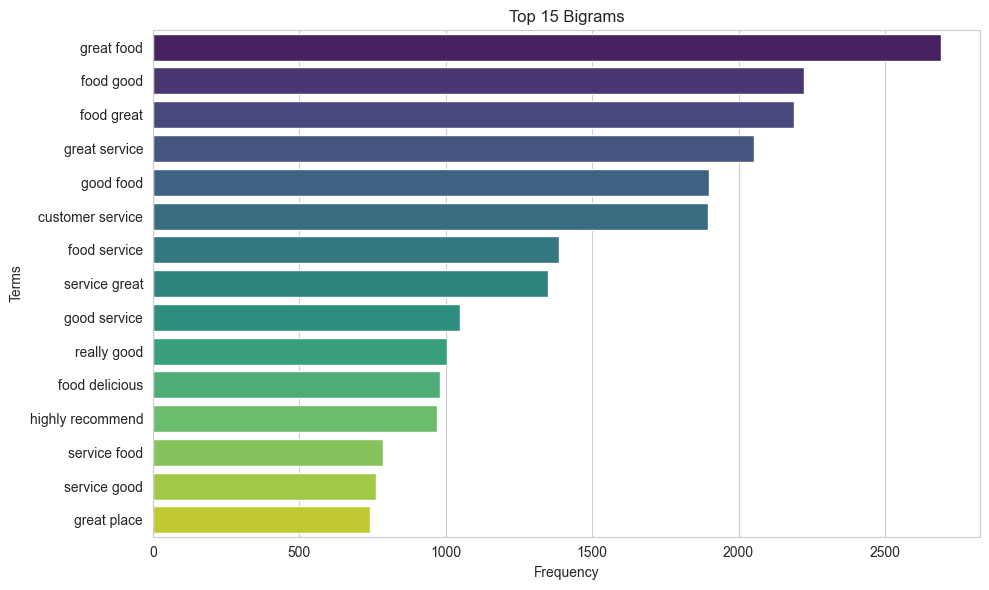

In [29]:
sns.set_style("whitegrid")


def plot_top_ngrams(corpus, n=1, top_k=15, title="Top N-grams"):
    """
    Plots the most frequent n-grams (1 word or 2 words) excluding standard English stopwords.
    """
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english").fit(corpus)

    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    df_ngram = pd.DataFrame(words_freq, columns=["Ngram", "Count"])

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x="Count",
        y="Ngram",
        hue="Ngram",
        data=df_ngram,
        palette="viridis",
        legend=False,
    )

    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Terms")
    plt.tight_layout()
    plt.show()


# Top Unigrams
plot_top_ngrams(atlanta_rest["raw_content"], n=1, top_k=25, title="Top 25 Unigrams")

# Top Bigrams
plot_top_ngrams(atlanta_rest["raw_content"], n=2, title="Top 15 Bigrams")


In [ ]:
def plot_cuisine_comparison(df, cat1, cat2, col_name="clean_text"):
    """
    Compares vocabulary of two cuisines using a specified column.
    """
    subset = df[df["categoryName"].isin([cat1, cat2])].copy()

    vec = CountVectorizer(stop_words="english", max_features=20).fit(subset[col_name])

    bag_cat1 = vec.transform(subset[subset["categoryName"] == cat1][col_name]).sum(
        axis=0
    )
    bag_cat2 = vec.transform(subset[subset["categoryName"] == cat2][col_name]).sum(
        axis=0
    )

    words = vec.get_feature_names_out()
    data = pd.DataFrame(
        {
            "word": list(words) * 2,
            "count": bag_cat1.tolist()[0] + bag_cat2.tolist()[0],
            "category": [cat1] * len(words) + [cat2] * len(words),
        }
    )

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=data.sort_values("count", ascending=False),
        x="count",
        y="word",
        hue="category",
        palette="viridis",
    )
    plt.title(f"Vocabulary Comparison: {cat1} vs {cat2}\n(Column: {col_name})")
    plt.xlabel("Frequency")
    plt.ylabel("")
    plt.show()


Stopwords configured: 336 words.


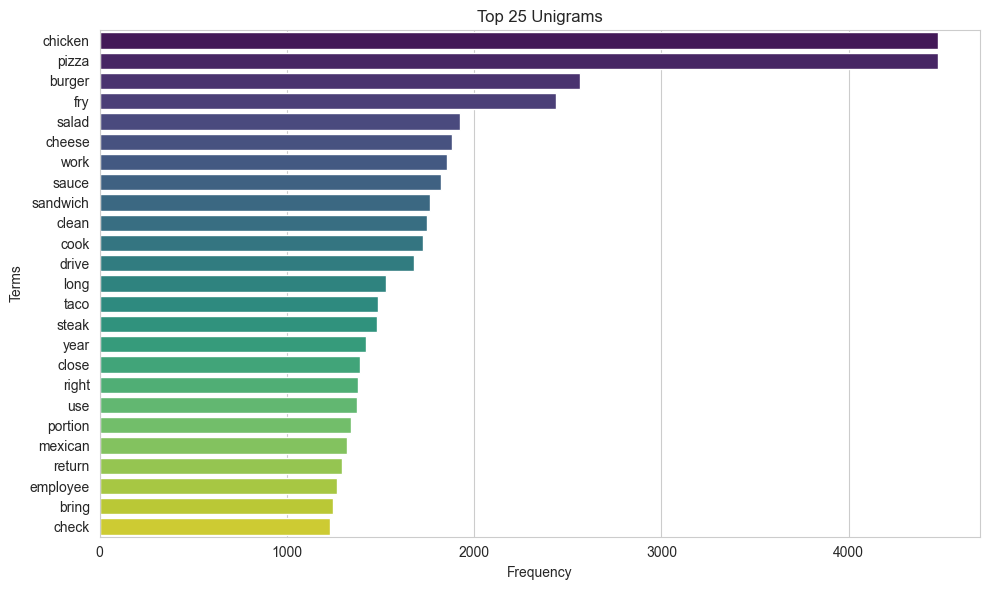

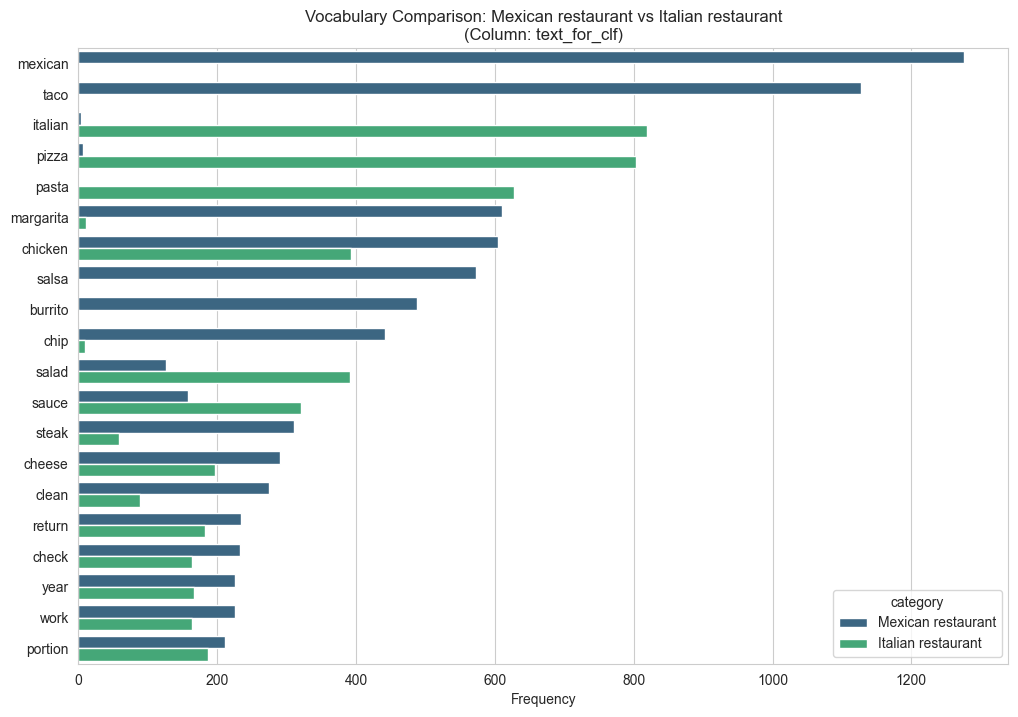

In [27]:
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith("J"):
        return wordnet.ADJ
    elif nltk_tag.startswith("V"):
        return wordnet.VERB
    elif nltk_tag.startswith("N"):
        return wordnet.NOUN
    elif nltk_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


base_stopwords = set(stopwords.words("english"))

domain_specific_list = [
    # Context / Nouns
    "food",
    "restaurant",
    "place",
    "service",
    "staff",
    "manager",
    "server",
    "waiter",
    "waitress",
    "table",
    "menu",
    "order",
    "location",
    "atmosphere",
    "experience",
    "visit",
    "meal",
    "dinner",
    "lunch",
    "breakfast",
    "customer",
    "people",
    "person",
    "family",
    "friend",
    "wife",
    "husband",
    "kid",
    "money",
    "bill",
    "review",
    "minute",
    "hour",
    "time",
    "star",
    "atlanta",
    "area",
    "spot",
    "thing",
    "way",
    "lot",
    "bit",
    "price",
    "quality",
    "bar",
    "drink",
    "option",
    "selection",
    "night",
    "day",
    "today",
    "tonight",
    "side",
    "plate",
    "dish",
    "flavor",
    "taste",
    # Verbs (Lemmas)
    "come",
    "go",
    "get",
    "eat",
    "try",
    "wait",
    "make",
    "want",
    "know",
    "think",
    "take",
    "say",
    "tell",
    "ask",
    "give",
    "look",
    "feel",
    "enjoy",
    "pay",
    "sit",
    "love",
    "like",
    "serve",
    "leave",
    "need",
    "start",
    # Descriptors / Adjectives
    "good",
    "great",
    "nice",
    "best",
    "amazing",
    "delicious",
    "excellent",
    "wonderful",
    "fantastic",
    "perfect",
    "bad",
    "terrible",
    "horrible",
    "fresh",
    "tasty",
    "friendly",
    "awesome",
    "recommend",
    "highly",
    "really",
    "just",
    "definitely",
    "absolutely",
    "pretty",
    "quite",
    "maybe",
    "probably",
    "actually",
    "sure",
    "better",
    "little",
    "big",
    "small",
    "super",
    "happy",
    "new",
    "busy",
    "slow",
    "fast",
    "hot",
    "cold",
    "authentic",
    "attentive",
    "fine",
    "ok",
    "okay",
    "average",
    "huge",
    "worth",
    "amaze",
    "favorite",
    # Grammar/Fragments
    "wa",
    "ha",
    "le",
    "u",
    "ve",
    "ll",
    "re",
    "m",
    "d",
    "s",
    "t",
    "don",
    "did",
    "not",
    "no",
    "yes",
]

final_stopwords = base_stopwords.union(domain_specific_list)
print(f"Stopwords configured: {len(final_stopwords)} words.")

lemmatizer = WordNetLemmatizer()


def processing_pipeline_extended(text):
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)

    clean_tokens = []
    clean_tags = []

    for word, tag in tagged_tokens:
        word_lower = word.lower()
        if word_lower.isalpha():
            lemma = lemmatizer.lemmatize(word_lower, get_wordnet_pos(tag))
            if lemma not in final_stopwords and len(lemma) > 2:
                clean_tokens.append(lemma)
                clean_tags.append(tag)

    return " ".join(clean_tokens), clean_tokens, clean_tags


processed_series = atlanta_rest["clean_text"].apply(processing_pipeline_extended)
(
    atlanta_rest["text_for_clf"],
    atlanta_rest["tokens_for_clf"],
    atlanta_rest["pos_tags_for_clf"],
) = zip(*processed_series)
plot_top_ngrams(atlanta_rest["text_for_clf"], n=1, top_k=25, title="Top 25 Unigrams")
plot_cuisine_comparison(
    atlanta_rest, "Mexican restaurant", "Italian restaurant", col_name="text_for_clf"
)

In [28]:
atlanta_rest

,title,categoryName,reviewsCount,stars,raw_content,word_count,clean_text,text_for_clf,tokens_for_clf,pos_tags_for_clf
0,The Optimist,Seafood restaurant,3349,5.0,"One word amazing!! The red fish, halibut, fr...",24,"one word amazing!! the red fish, halibut, frie...",one word red fish halibut fry rice broccolini ...,"[one, word, red, fish, halibut, fry, rice, bro...","[CD, NN, JJ, NN, NN, VBN, NN, NN, VB, NN, NN]"
1,The Optimist,Seafood restaurant,3349,5.0,First time here and the food is great and the ...,13,first time here and the food is great and the ...,first,[first],[JJ]
2,The Optimist,Seafood restaurant,3349,5.0,I recently had the pleasure of dining at Optim...,339,i recently had the pleasure of dining at optim...,recently pleasure din optimist let absolute tr...,"[recently, pleasure, din, optimist, let, absol...","[RB, NN, VBG, NN, VB, JJ, NN, NN, VBD, NN, JJ,..."
3,The Optimist,Seafood restaurant,3349,5.0,Beautiful atmosphere and delicious food. All o...,83,beautiful atmosphere and delicious food. all o...,beautiful flavorful overall oyster mussel sauc...,"[beautiful, flavorful, overall, oyster, mussel...","[NN, JJ, JJ, NNS, NNS, NN, JJ, NN, JJ, VBG, NN..."
4,The Optimist,Seafood restaurant,3349,5.0,We had a wonderful dinner at the Optimist. Our...,22,we had a wonderful dinner at the optimist. our...,optimist group oyster cocktail,"[optimist, group, oyster, cocktail]","[NN, NN, NNS, NNS]"
...,...,...,...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,449,5.0,Friday night dinner was Chicken Francaise. Jor...,13,friday night dinner was chicken francaise. jor...,friday chicken francaise jordan,"[friday, chicken, francaise, jordan]","[JJ, VBN, NN, NN]"
53562,L On North,New American restaurant,449,5.0,Great dinner.... Yay Jordan!!!!!!,4,great dinner.... yay jordan!!!!!!,yay jordan,"[yay, jordan]","[VBZ, NN]"
53563,L On North,New American restaurant,449,5.0,Jordan was our server and he was fantastic! Gr...,10,jordan was our server and he was fantastic! gr...,jordan,[jordan],[NN]
53564,L On North,New American restaurant,449,5.0,Jordan was an amazing server! Great delicious...,16,jordan was an amazing server! great delicious ...,jordan wine social distancing practice din,"[jordan, wine, social, distancing, practice, din]","[NN, NN, JJ, NN, NNS, VBG]"


#### Word Cloud Visualisation

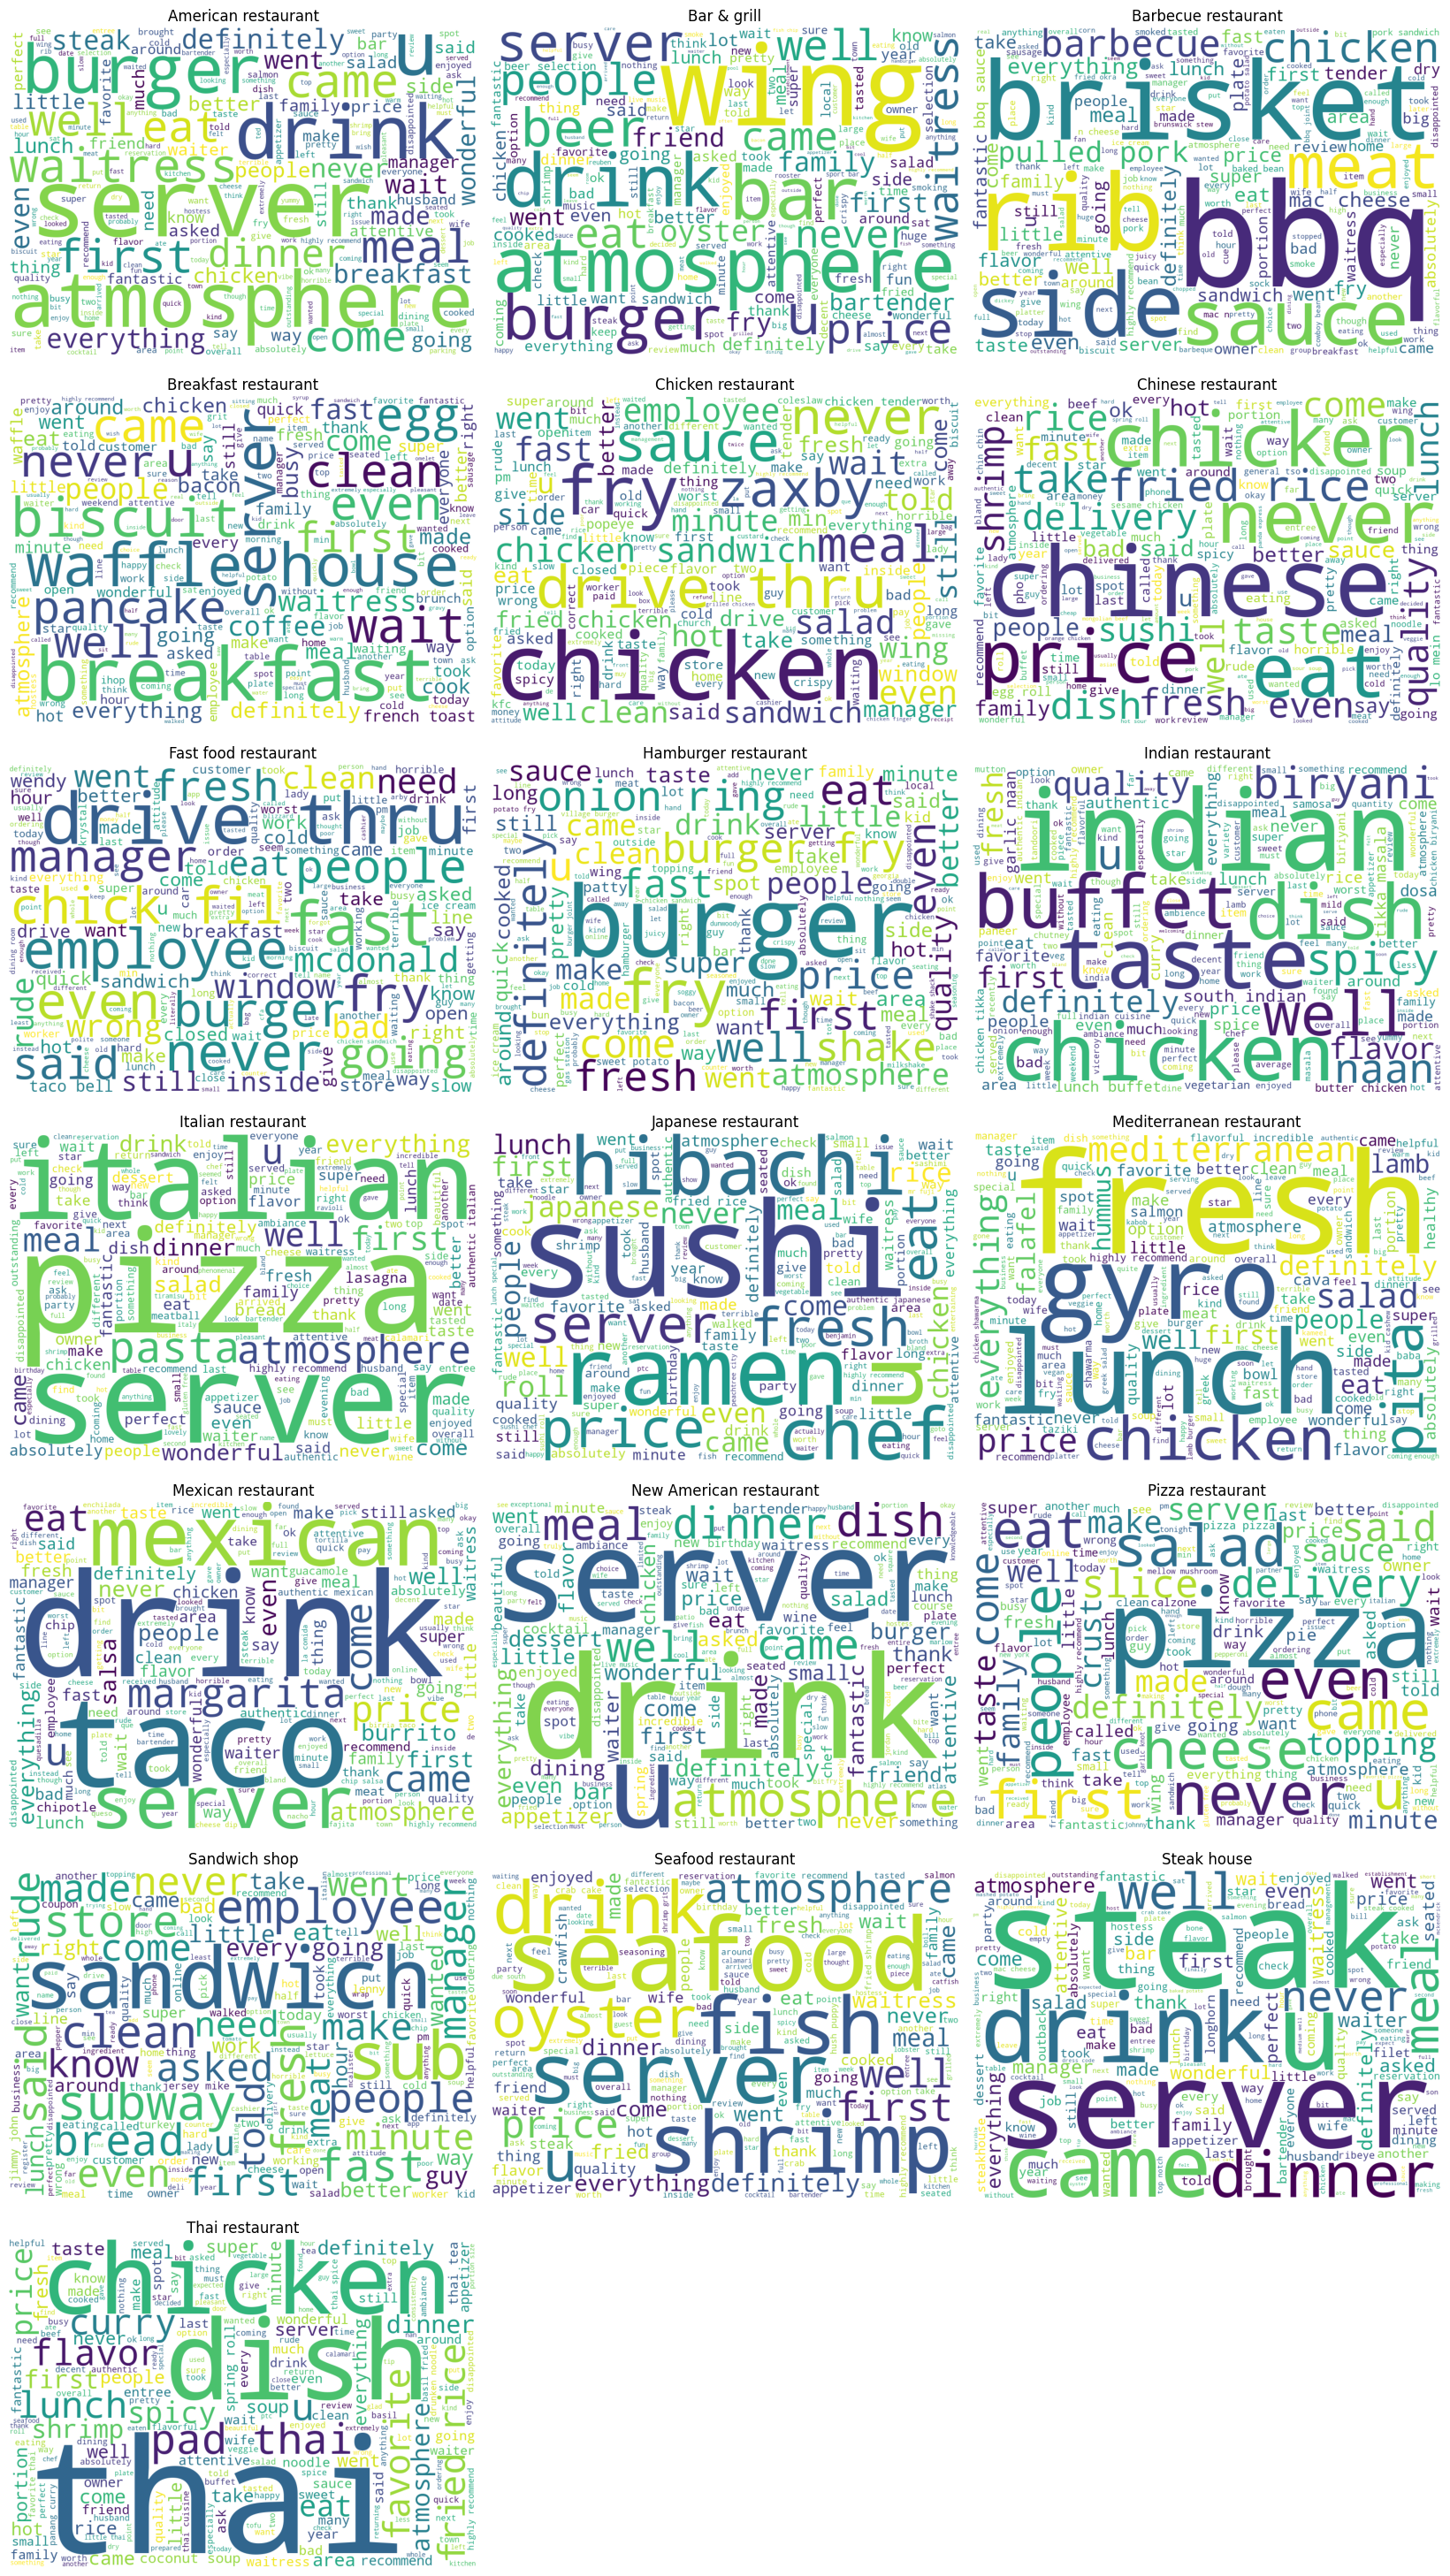

In [36]:
# group all processed text by category
texts_by_cat = (
    atlanta_rest.groupby("categoryName")["processed_text"]
    .apply(lambda s: " ".join(s))
    .to_dict()
)

os.makedirs("wordclouds", exist_ok=True)

# generate + save
for cat, text in texts_by_cat.items():
    wc = WordCloud(width=1000, height=700, background_color="white").generate(text)
    wc.to_file(f"wordclouds/{cat}.png")

# show all in grid
cats = list(texts_by_cat.keys())
n = len(cats)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(5.5 * cols, 4.2 * rows))
i = 1
for cat in cats:
    img = plt.imread(f"wordclouds/{cat}.png")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cat)
    i += 1
plt.tight_layout()
plt.show()


In [ ]:
# overall top words
all_words = [word for tokens in atlanta_rest["norm_tokens"] for word in tokens]
Counter(all_words).most_common(20)

# top words per category
for cat, group in atlanta_rest.groupby("categoryName"):
    words = [word for tokens in group["norm_tokens"] for word in tokens]
    print(f"\nTop words in {cat}:")
    print(Counter(words).most_common(10))



Top words in American restaurant:
[('server', 630), ('u', 553), ('would', 487), ('atmosphere', 421), ('burger', 421), ('drink', 414), ('definitely', 395), ('chicken', 360), ('came', 349), ('well', 347)]

Top words in Bar & grill:
[('wing', 200), ('beer', 126), ('bar', 112), ('atmosphere', 103), ('u', 94), ('drink', 91), ('burger', 89), ('would', 82), ('server', 66), ('never', 66)]

Top words in Barbecue restaurant:
[('bbq', 362), ('brisket', 208), ('rib', 167), ('pork', 151), ('sauce', 139), ('side', 126), ('cheese', 126), ('meat', 100), ('pulled', 96), ('mac', 96)]

Top words in Breakfast restaurant:
[('breakfast', 492), ('waffle', 310), ('house', 266), ('biscuit', 244), ('egg', 230), ('server', 230), ('wait', 213), ('would', 180), ('u', 180), ('even', 176)]

Top words in Chicken restaurant:
[('chicken', 802), ('drive', 235), ('fry', 228), ('sandwich', 179), ('thru', 153), ('sauce', 148), ('fried', 135), ('would', 130), ('hot', 128), ('wait', 126)]

Top words in Chinese restaurant:
[

In [46]:
bigrams = Counter(ngrams(all_words, 2)).most_common(20)
bigrams

[(('highly', 'recommend'), 975),
 (('drive', 'thru'), 847),
 (('make', 'sure'), 402),
 (('would', 'recommend'), 399),
 (('even', 'though'), 363),
 (('top', 'notch'), 341),
 (('chick', 'fil'), 322),
 (('fried', 'rice'), 319),
 (('definitely', 'recommend'), 302),
 (('peachtree', 'city'), 294),
 (('ice', 'cream'), 275),
 (('waffle', 'house'), 272),
 (('chicken', 'sandwich'), 271),
 (('would', 'definitely'), 255),
 (('gluten', 'free'), 250),
 (('even', 'better'), 246),
 (('mac', 'cheese'), 233),
 (('dining', 'room'), 231),
 (('reasonable', 'price'), 225),
 (('portion', 'size'), 222)]

In [ ]:
atlanta_rest["sentiment"] = atlanta_rest["clean_text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

atlanta_rest["sentiment"]

0        0.250000
1        0.683333
2        0.441173
3        0.328906
4        0.933333
           ...   
53561    0.306667
53562    0.800000
53563    0.600000
53564    0.626667
53565    0.312121
Name: sentiment, Length: 51542, dtype: float64

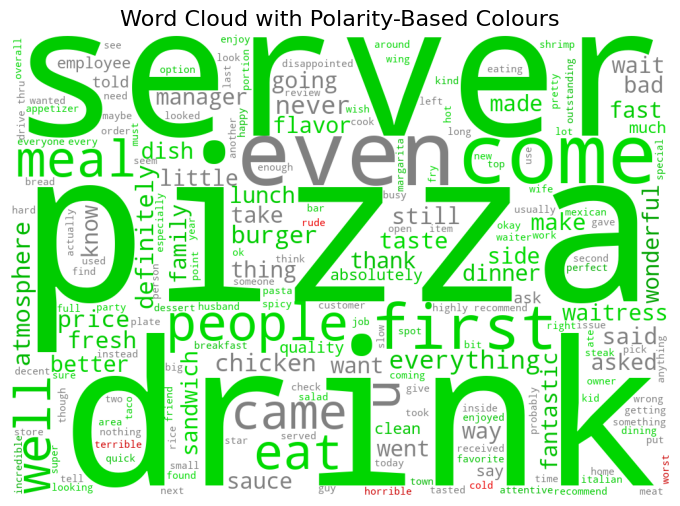

In [78]:
from collections import defaultdict

word_sentiment = defaultdict(list)

for _, row in atlanta_rest.iterrows():
    for word in row["norm_tokens"]:
        word_sentiment[word].append(row["sentiment"])

# average polarity per word
word_avg_sentiment = {w: sum(v) / len(v) for w, v in word_sentiment.items()}

from wordcloud import WordCloud
import matplotlib.pyplot as plt


def polarity_color_func(word, **kwargs):
    polarity = word_avg_sentiment.get(word, 0)
    # Map polarity to colour gradient
    if polarity > 0.2:
        return "hsl(120, 100%%, %d%%)" % int(
            50 - 30 * polarity
        )  # greenish for positive
    elif polarity < -0.1:
        return "hsl(0, 100%%, %d%%)" % int(50 + 30 * polarity)  # reddish for negative
    else:
        return "gray"  # neutral words


# Combine all processed text
all_text = " ".join(atlanta_rest["processed_text"])

# Create word cloud
wc = WordCloud(width=1000, height=700, background_color="white").generate(all_text)

# Recolour based on polarity
plt.figure(figsize=(10, 6))
plt.imshow(wc.recolor(color_func=polarity_color_func, random_state=3))
plt.axis("off")
plt.title("Word Cloud with Polarity-Based Colours", fontsize=16)
plt.show()


In [ ]:
def pos_counts(tags):
    counts = Counter(tags)
    return counts


pos_summary = atlanta_rest["pos_tags"].apply(pos_counts)
pos_summary

0        {'CD': 1, 'NN': 9, 'VBG': 1, 'DT': 1, 'JJ': 2,...
1        {'JJ': 3, 'NN': 3, 'RB': 1, 'CC': 2, 'DT': 2, ...
2        {'NN': 72, 'RB': 15, 'VBD': 26, 'DT': 40, 'IN'...
3        {'NN': 15, 'RB': 5, 'CC': 7, 'JJ': 14, 'DT': 1...
4        {'PRP': 1, 'VBD': 3, 'DT': 4, 'JJ': 4, 'NN': 3...
                               ...                        
53561    {'JJ': 3, 'NN': 4, 'VBD': 2, 'VBN': 1, 'RB': 2...
53562                         {'JJ': 1, 'NN': 2, 'NNS': 1}
53563    {'NN': 3, 'VBD': 2, 'PRP$': 1, 'CC': 1, 'PRP':...
53564    {'NN': 4, 'VBD': 1, 'DT': 1, 'JJ': 5, 'CC': 1,...
53565    {'JJ': 3, 'NN': 3, 'CC': 2, 'RB': 2, 'NNS': 1,...
Name: pos_tags, Length: 51542, dtype: object

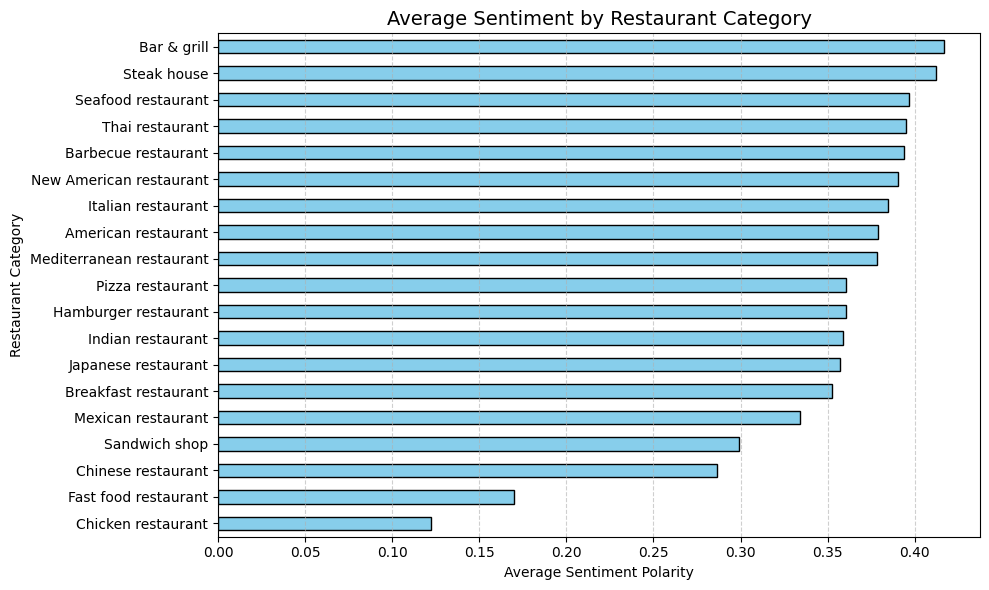

In [ ]:
# Group and sort by mean sentiment
sentiment_by_cat = (
    atlanta_rest.groupby("categoryName")["sentiment"].mean().sort_values(ascending=True)
)

# Plot
plt.figure(figsize=(10, 6))
sentiment_by_cat.plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Average Sentiment by Restaurant Category", fontsize=14)
plt.xlabel("Average Sentiment Polarity")
plt.ylabel("Restaurant Category")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

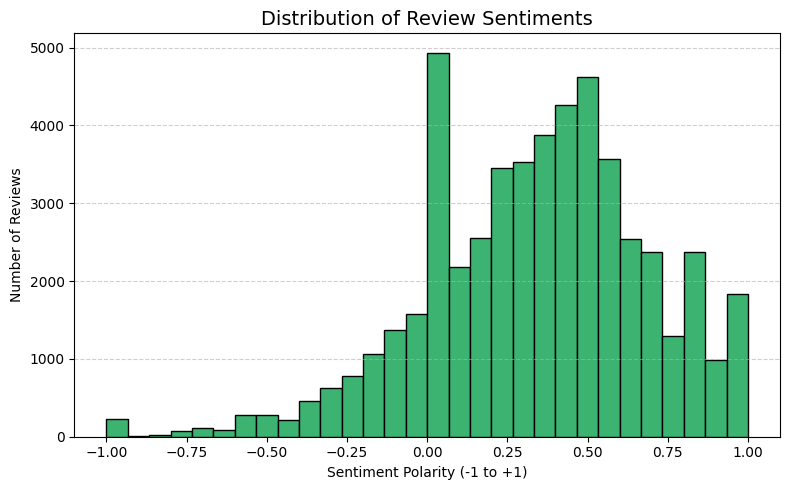

In [55]:
plt.figure(figsize=(8, 5))
plt.hist(atlanta_rest["sentiment"], bins=30, color="mediumseagreen", edgecolor="black")
plt.title("Distribution of Review Sentiments", fontsize=14)
plt.xlabel("Sentiment Polarity (-1 to +1)")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Co-occurrence

In [ ]:
# Count word pairs (within each review)
pair_counts = Counter()

for tokens in atlanta_rest["norm_tokens"]:
    for pair in combinations(set(tokens), 2):  # use set() to avoid duplicates
        pair_counts[tuple(sorted(pair))] += 1

# Get most common co-occurring pairs
co_occurrence = pair_counts.most_common(20)
co_occurrence

[(('highly', 'recommend'), 997),
 (('drive', 'thru'), 750),
 (('recommend', 'would'), 732),
 (('server', 'u'), 611),
 (('came', 'u'), 576),
 (('burger', 'fry'), 575),
 (('u', 'would'), 533),
 (('could', 'would'), 531),
 (('come', 'would'), 511),
 (('even', 'would'), 500),
 (('make', 'sure'), 496),
 (('came', 'would'), 495),
 (('definitely', 'would'), 490),
 (('even', 'u'), 486),
 (('definitely', 'recommend'), 480),
 (('never', 'would'), 476),
 (('drink', 'u'), 474),
 (('took', 'u'), 469),
 (('never', 'u'), 464),
 (('came', 'server'), 464)]

In [69]:
def cooccurrence_network_generator(
    cooccurrence_matrix_df, n_highest_words=30, output=None
):
    """
    Visualises a cleaner co-occurrence network for top n words.
    """
    import matplotlib.pyplot as plt
    import networkx as nx

    # Filter to top n words
    filtered_df = cooccurrence_matrix_df.iloc[:n_highest_words, :n_highest_words]
    graph = nx.Graph()

    # Add nodes sized by frequency
    for word in filtered_df.columns:
        graph.add_node(word, size=filtered_df[word].sum())

    # Add edges only for meaningful co-occurrences
    for word1 in filtered_df.columns:
        for word2 in filtered_df.columns:
            weight = filtered_df.loc[word1, word2]
            if word1 != word2 and weight > 2:  # ignore very weak links
                graph.add_edge(word1, word2, weight=weight)

    # Create figure
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(graph, k=0.6, seed=42)

    # Make edges thinner and lighter
    edge_weights = [0.02 * graph[u][v]["weight"] for u, v in graph.edges()]
    edge_weights = [min(w, 3) for w in edge_weights]  # cap edge thickness
    nx.draw_networkx_edges(
        graph, pos, edge_color="lightgray", width=edge_weights, alpha=0.5
    )

    # Make nodes smaller and softly coloured
    node_sizes = [data["size"] * 0.3 for _, data in graph.nodes(data=True)]
    nx.draw_networkx_nodes(
        graph, pos, node_color="skyblue", node_size=node_sizes, alpha=0.8
    )

    # Text labels
    nx.draw_networkx_labels(
        graph, pos, font_size=9, font_weight="semibold", font_color="black"
    )

    plt.title("Word Co-occurrence Network (Top Words)", fontsize=15, pad=20)
    plt.axis("off")
    plt.show()

    if output == "return":
        return plt.gcf()

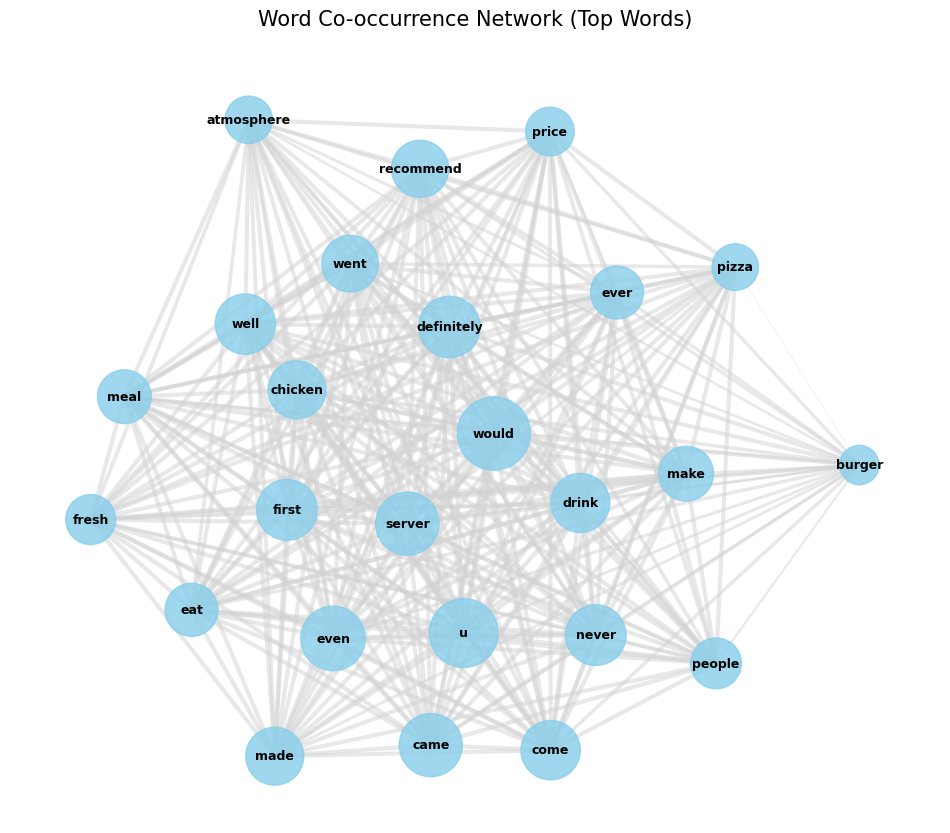

In [71]:
co_matrix = build_cooccurrence_matrix(atlanta_rest["norm_tokens"], top_n=40)
cooccurrence_network_generator(co_matrix, n_highest_words=25)

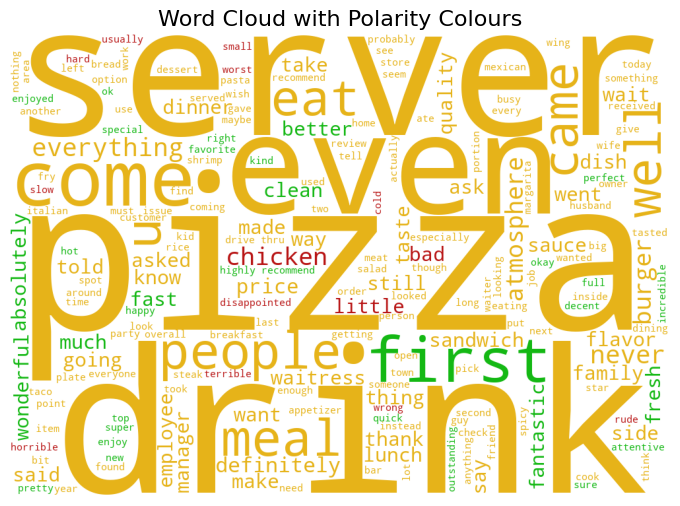

In [ ]:
# Define a function to compute polarity colour
def polarity_color(word, font_size, position, orientation, random_state=None, **kwargs):
    polarity = TextBlob(word).sentiment.polarity
    # Map polarity (-1 to 1) to colour scale
    if polarity > 0.1:
        return "hsl(120, 80%, 40%)"  # greenish (positive)
    elif polarity < -0.1:
        return "hsl(0, 80%, 40%)"  # reddish (negative)
    else:
        return "hsl(45, 80%, 50%)"  # yellowish (neutral)


# Combine all processed text
all_text = " ".join(atlanta_rest["processed_text"])

# Create a colour-coded word cloud
wc = WordCloud(width=1000, height=700, background_color="white").generate(all_text)
plt.figure(figsize=(10, 6))
plt.imshow(wc.recolor(color_func=polarity_color, random_state=3))
plt.axis("off")
plt.title("Word Cloud with Polarity Colours", fontsize=16)
plt.show()


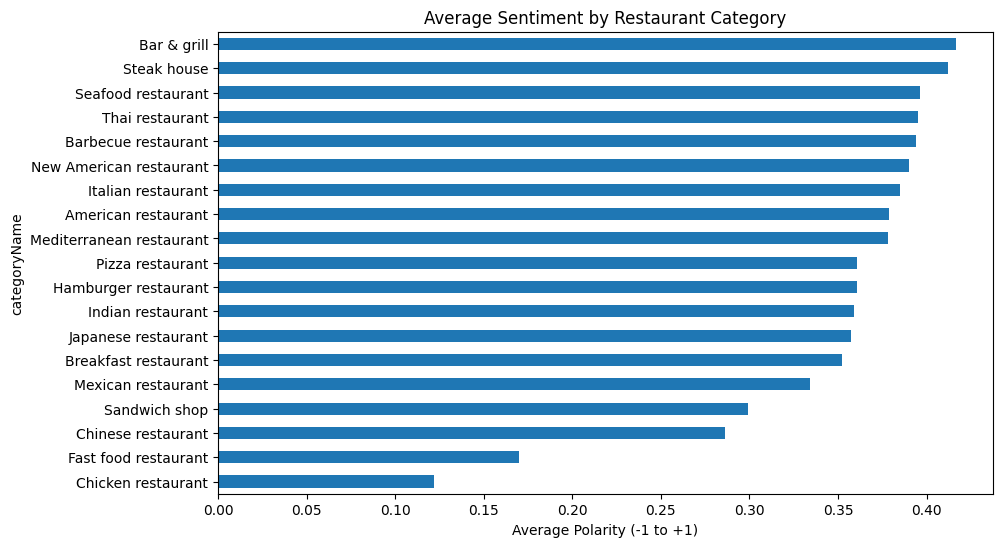

In [79]:
sentiment_by_cat = (
    atlanta_rest.groupby("categoryName")["sentiment"].mean().sort_values()
)
sentiment_by_cat.plot(
    kind="barh", figsize=(10, 6), title="Average Sentiment by Restaurant Category"
)
plt.xlabel("Average Polarity (-1 to +1)")
plt.show()